InvoiceNo         0
StockCode         0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1205
Country           0
dtype: int64
Original rows: 5000
Cleaned rows: 3725
InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
            Recency  Frequency  Monetary
CustomerID                              
12431.0           2          1    358.25
12433.0           2          1   1919.14
12583.0           2          1    855.86
12662.0           2          1    261.48
12748.0           1          2      9.20
            Recency  Frequency  Monetary
CustomerID                              
12431.0         1.0   0.000000  0.037140
12433.0         1.0   0.000000  0.203225
12583.0         1.0   0.000000  0.090088
12662.0         1.0   0.000000  0.026844
12748.0         0.0   0.030303  0.000000


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

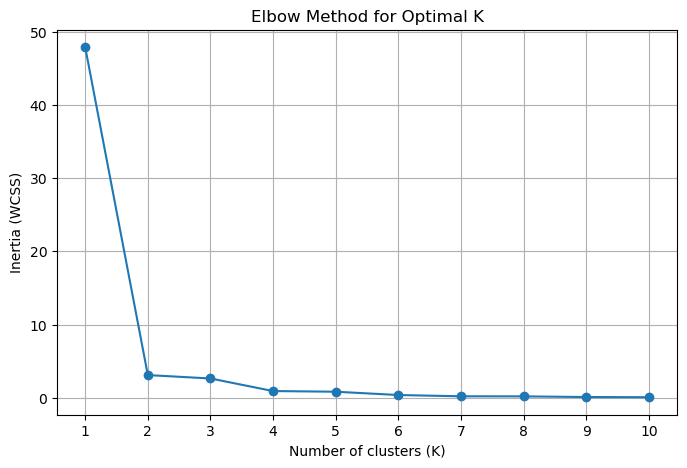

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12431.0           2          1    358.25        0
12433.0           2          1   1919.14        0
12583.0           2          1    855.86        0
12662.0           2          1    261.48        0
12748.0           1          2      9.20        1
...             ...        ...       ...      ...
18085.0           2          1    303.90        0
18144.0           2          1    165.05        0
18168.0           1          1    164.95        1
18229.0           2          1    344.20        0
18239.0           1          1    438.10        1

[179 rows x 4 columns]
            Recency  Frequency  Monetary  Cluster     Segment
CustomerID                                                   
12431.0           2          1    358.25        0   Low-Value
12433.0           2          1   1919.14        0   Low-Value
12583.0           2          1    855.86        0   Low-Value
12662.0         

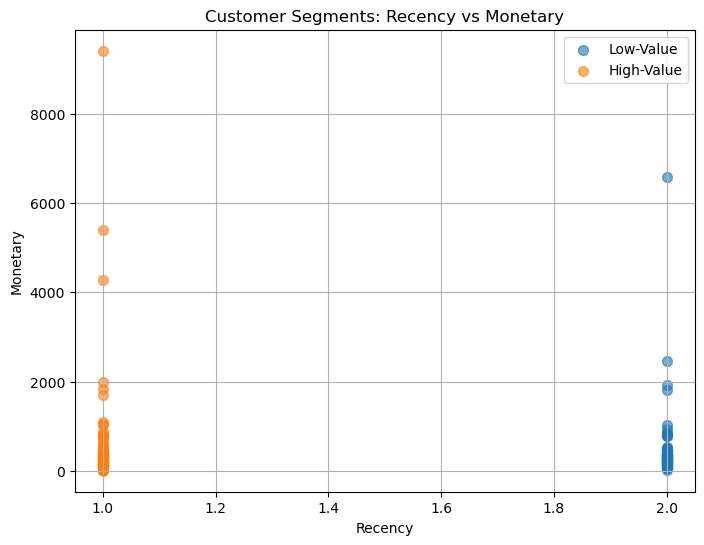

Models saved successfully!


In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
df=pd.read_csv("Online Retail.csv")
df.head()
print(df.isnull().sum())
df.shape
#Data Cleaning
# 1️⃣ Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    
# 2️⃣ Apply all cleaning conditions together
df_clean = df[
    (df['CustomerID'].notna()) &     # Remove rows with missing CustomerID
    (df['Quantity'] > 0) &           # Keep only positive quantities
    (df['UnitPrice'] > 0) &          # Keep only positive prices
    (df['InvoiceDate'].notna())      # Remove invalid dates (if any)
]

# 3️⃣ Reset index after cleaning
df_clean.reset_index(drop=True, inplace=True)
print("Original rows:", df.shape[0])
print("Cleaned rows:", df_clean.shape[0])
print(df_clean.isnull().sum())
#--------Feature Engineering-------------
#----RFM ANALYSIS(Recency,Frequecny,Monetary)---------
today_date=df_clean['InvoiceDate'].max()+pd.Timedelta(days=1)
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Quantity': lambda x: (x * df_clean.loc[x.index, 'UnitPrice']).sum()  # Monetary
})
rfm.rename(columns={'InvoiceDate':'Recency', 'InvoiceNo':'Frequency', 'Quantity':'Monetary'}, inplace=True)


# 5️⃣ Check the result
print(rfm.head())
#Scalinf RFM Features

# Create a copy of RFM table (without CustomerID for scaling)
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Initialize the scaler
scaler = MinMaxScaler()   # Scales features between 0 and 1

# Fit the scaler and transform the features
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled array back to a DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

# Check the scaled data
print(rfm_scaled.head())

#---------CHECKING ELBOW METHOD-------------

# 1️⃣ Choose range of K to test
K_range = range(1, 11)   # K = 1 to 10
inertia_values = []       # to store inertia for each K

# 2️⃣ Loop over K and fit K-Means
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)          # Fit on scaled RFM features
    inertia_values.append(kmeans.inertia_)  # Store inertia

# 3️⃣ Plot K vs Inertia
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

#-------Applying KMeans Algorithm-------
# 1️⃣ Initialize K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)

# 2️⃣ Fit K-Means on scaled RFM features
kmeans.fit(rfm_scaled)

# 3️⃣ Assign cluster labels to each customer
rfm['Cluster'] = kmeans.labels_  # adds a new column 'Cluster'

# 4️⃣ Check cluster assignments
print(rfm)
segment_map = {0: 'Low-Value', 1: 'High-Value'}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Quick check
print(rfm[['Recency','Frequency','Monetary','Cluster','Segment']].head())

# 5️⃣ Analyze clusters by their average RFM values
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'  # number of customers in each cluster
}).rename(columns={'Cluster': 'Num_Customers'})

print(cluster_summary)
#saving model and scalar
import pickle

# Save K-Means model
with open('CustomerSegmentation(KMeans).pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save MinMaxScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models saved successfully!")
